<a href="https://colab.research.google.com/github/hyperpipe-kr/colab-examples/blob/main/05_LSTM_%ED%99%9C%EC%9A%A9_%EC%A3%BC%EA%B0%80_%EC%98%88%EC%B8%A1_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM을 활용한 주가 예측 모델

다음과 같은 **프로세스 파이프라인**으로 주가 예측을 진행합니다.

- FinanceDataReader를 활용하여 주가 데이터 받아오기
- TensorFlow Dataset 클래스를 활용하여 주가 데이터 구축
- LSTM 을 활용한 주가 예측 모델 구축

## 필요한 모듈 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

%matplotlib inline
warnings.filterwarnings('ignore')

# apt-get을 통해 나눔 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.font_manager as fm

# 설치된 나눔 폰트를 찾아 fontManager에 직접 추가합니다.
for fontpath in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'Nanum' in fontpath:
        fm.fontManager.addfont(fontpath)

# 폰트 설정 및 마이너스 기호 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('NanumGothic font installed and applied.')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

## 데이터 (FinanceDataReader)

**FinanceDataReader**는 주가 데이터를 편리하게 가져올 수 있는 파이썬 패키지입니다.

- [GitHub Repo](https://github.com/FinanceData/FinanceDataReader)

**FinanceDataReader**가 아직 설치 되지 않으신 분들은 아래의 주석을 해제한 후 명령어로 설치해 주시기 바랍니다.

In [2]:
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.1 MB/s eta 0:00:00


In [3]:
import FinanceDataReader as fdr

In [4]:
# 삼성전자(005930) 전체 (1996-11-05 ~ 현재)
samsung = fdr.DataReader('005930')

매우 편리하게 삼성전자 주가 데이터를 `DataFrame`형식으로 받아옵니다.

기본 **오름차순 정렬**이 된 데이터임을 알 수 있습니다.

### 컬럼 설명

- `Open`:   시가
- `High`:   고가
- `Low`:    저가
- `Close`:  종가
- `Volume`: 거래량
- `Change`: 대비

In [5]:
samsung.tail()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-07-14,255000,270000,247000,263000,40086496,0.033399
2026-07-15,283500,284500,273000,279500,24873414,0.062738
2026-07-16,264500,265500,252500,255000,27001478,-0.087657
2026-07-20,241000,257500,240000,244000,26804038,-0.043137
2026-07-21,247000,263500,243000,259000,20358404,0.061475


**미국 주식 데이터**도 가져올 수 있습니다.

In [6]:
# Apple(AAPL), 애플
apple = fdr.DataReader('AAPL')

In [ ]:
apple.tail()

,Open,High,Low,Close,Volume,Adj Close
2026-07-14,313.760010,316.190002,311.910004,314.859985,36336800,314.859985
2026-07-15,317.619995,328.730011,317.320007,327.500000,60957600,327.500000
2026-07-16,328.010010,334.679993,326.790009,333.260010,62970600,333.260010
2026-07-17,331.980011,334.989990,329.000000,333.739990,63407100,333.739990
2026-07-20,333.510010,333.709991,323.679993,326.589996,53396600,326.589996


다음과 같이 `2017`을 같이 넘겨주면, 해당 시점 이후의 주식 데이터를 가져옵니다.

In [7]:
# Apple(AAPL), 애플
apple = fdr.DataReader('AAPL', '2017')

In [8]:
apple.head()

,Open,High,Low,Close,Volume,Adj Close
2017-01-03,28.950001,29.082500,28.690001,29.037500,115127600,26.721235
2017-01-04,28.962500,29.127501,28.937500,29.004999,84472400,26.691334
2017-01-05,28.980000,29.215000,28.952499,29.152500,88774400,26.827065
2017-01-06,29.195000,29.540001,29.117500,29.477501,127007600,27.126141
2017-01-09,29.487499,29.857500,29.485001,29.747499,134247600,27.374607


**시작**과 **끝** 날짜를 지정하여 범위 데이터를 가져올 수 있습니다.

In [9]:
# Ford(F), 1980-01-01 ~ 2019-12-30 (40년 데이터)
ford = fdr.DataReader('F', '1980-01-01', '2019-12-30')

In [10]:
ford.head()

,Open,High,Low,Close,Volume,Adj Close
1980-01-02,1.297609,1.328022,1.287471,1.287471,2044376,0.204159
1980-01-03,1.287471,1.287471,1.267196,1.287471,2816257,0.204159
1980-01-04,1.287471,1.287471,1.272265,1.277334,3038203,0.202552
1980-01-07,1.277334,1.287471,1.267196,1.267196,2251526,0.200944
1980-01-08,1.267196,1.292540,1.257059,1.292540,4069022,0.204963


In [11]:
ford.tail()

,Open,High,Low,Close,Volume,Adj Close
2019-12-20,9.50,9.54,9.44,9.48,50191200,6.909802
2019-12-23,9.50,9.57,9.40,9.44,54784400,6.880647
2019-12-24,9.44,9.49,9.43,9.47,11881600,6.902514
2019-12-26,9.47,9.49,9.43,9.45,28961300,6.887936
2019-12-27,9.45,9.46,9.35,9.36,28272800,6.822337


그 밖에 **금, 은과 같은 현물**, **달러와 같은 화폐** 데이터도 가져올 수 있습니다.

더욱 자세한 내용은 [GitHub 페이지 링크](https://github.com/FinanceData/FinanceDataReader)를 참고해 보시기 바랍니다.

**삼성전자** 주가데이터를 가져옵니다.

In [57]:
# 삼성전자 주식코드: 005930
# STOCK_CODE = '005930'
STOCK_CODE = '035720'

In [58]:
stock = fdr.DataReader(STOCK_CODE)

In [59]:
stock.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-04-25,14551,14731,14390,14511,76046,NaN
2014-04-28,14531,15394,14531,14873,191976,0.024947
2014-04-29,14932,15173,14832,15033,83148,0.010758
2014-04-30,15153,15213,14872,15033,74965,0.000000
2014-05-02,15013,15193,15013,15013,76566,-0.001330


In [60]:
stock.tail()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-07-14,35050,35050,33700,33850,2147915,-0.025899
2026-07-15,34600,35950,34550,34900,1890167,0.031019
2026-07-16,34700,36450,34150,35900,2680070,0.028653
2026-07-20,35600,36200,34350,35050,1867585,-0.023677
2026-07-21,34900,35900,34250,35300,1313524,0.007133


In [61]:
stock.index

DatetimeIndex(['2014-04-25', '2014-04-28', '2014-04-29', '2014-04-30',
               '2014-05-02', '2014-05-07', '2014-05-08', '2014-05-09',
               '2014-05-12', '2014-05-13',
               ...
               '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10',
               '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16',
               '2026-07-20', '2026-07-21'],
              dtype='datetime64[ns]', name='Date', length=3000, freq=None)

위에서 보시는 바와 같이 index가 `DatetimeIndex`로 지정되어 있습니다.

`DatetimeIndex`로 정의되어 있다면, 아래와 같이 연도, 월, 일을 쪼갤 수 있으며, **월별, 연도별 피벗데이터**를 만들때 유용하게 활용할 수 있습니다.

In [62]:
stock['Year'] = stock.index.year
stock['Month'] = stock.index.month
stock['Day'] = stock.index.day

In [63]:
stock.head()

,Open,High,Low,Close,Volume,Change,Year,Month,Day
Date,,,,,,,,,
2014-04-25,14551,14731,14390,14511,76046,NaN,2014,4,25
2014-04-28,14531,15394,14531,14873,191976,0.024947,2014,4,28
2014-04-29,14932,15173,14832,15033,83148,0.010758,2014,4,29
2014-04-30,15153,15213,14872,15033,74965,0.000000,2014,4,30
2014-05-02,15013,15193,15013,15013,76566,-0.001330,2014,5,2


## 시각화

Text(0, 0.5, 'price')

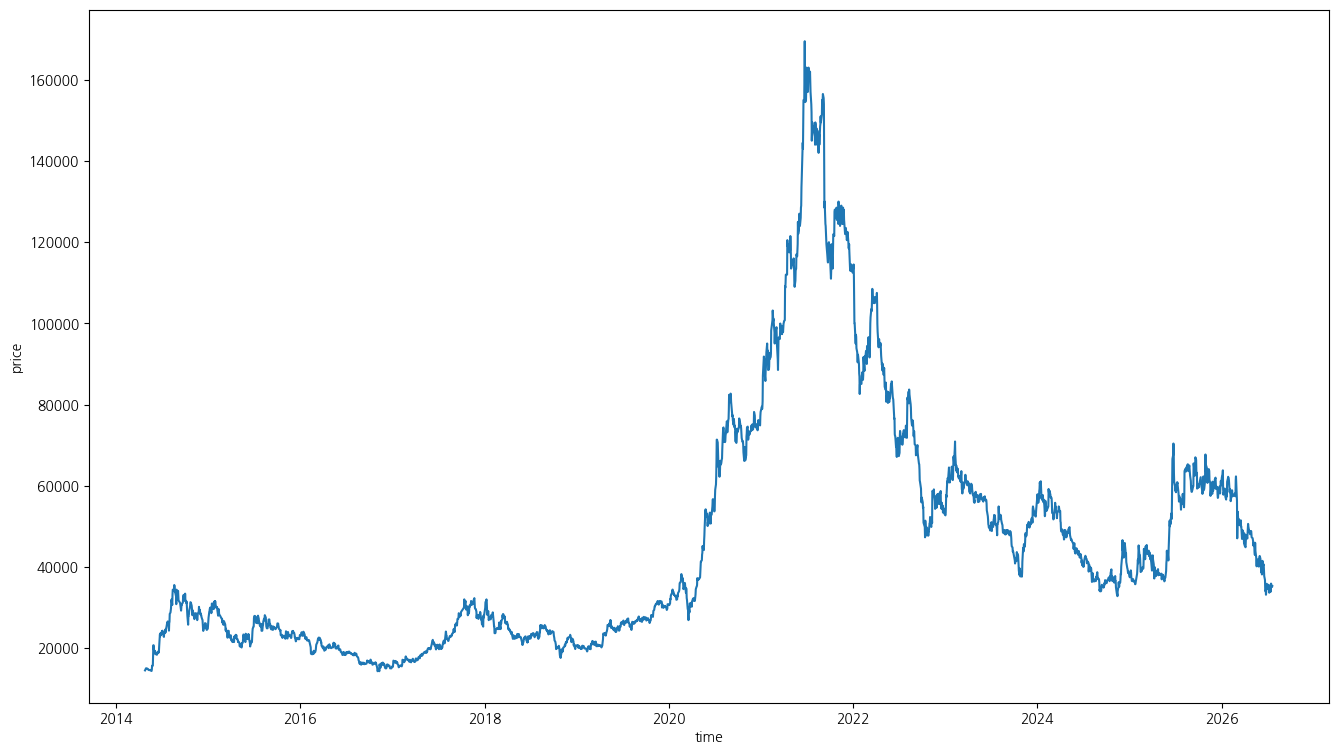

In [64]:
plt.figure(figsize=(16, 9))
sns.lineplot(y=stock['Close'], x=stock.index)
plt.xlabel('time')
plt.ylabel('price')

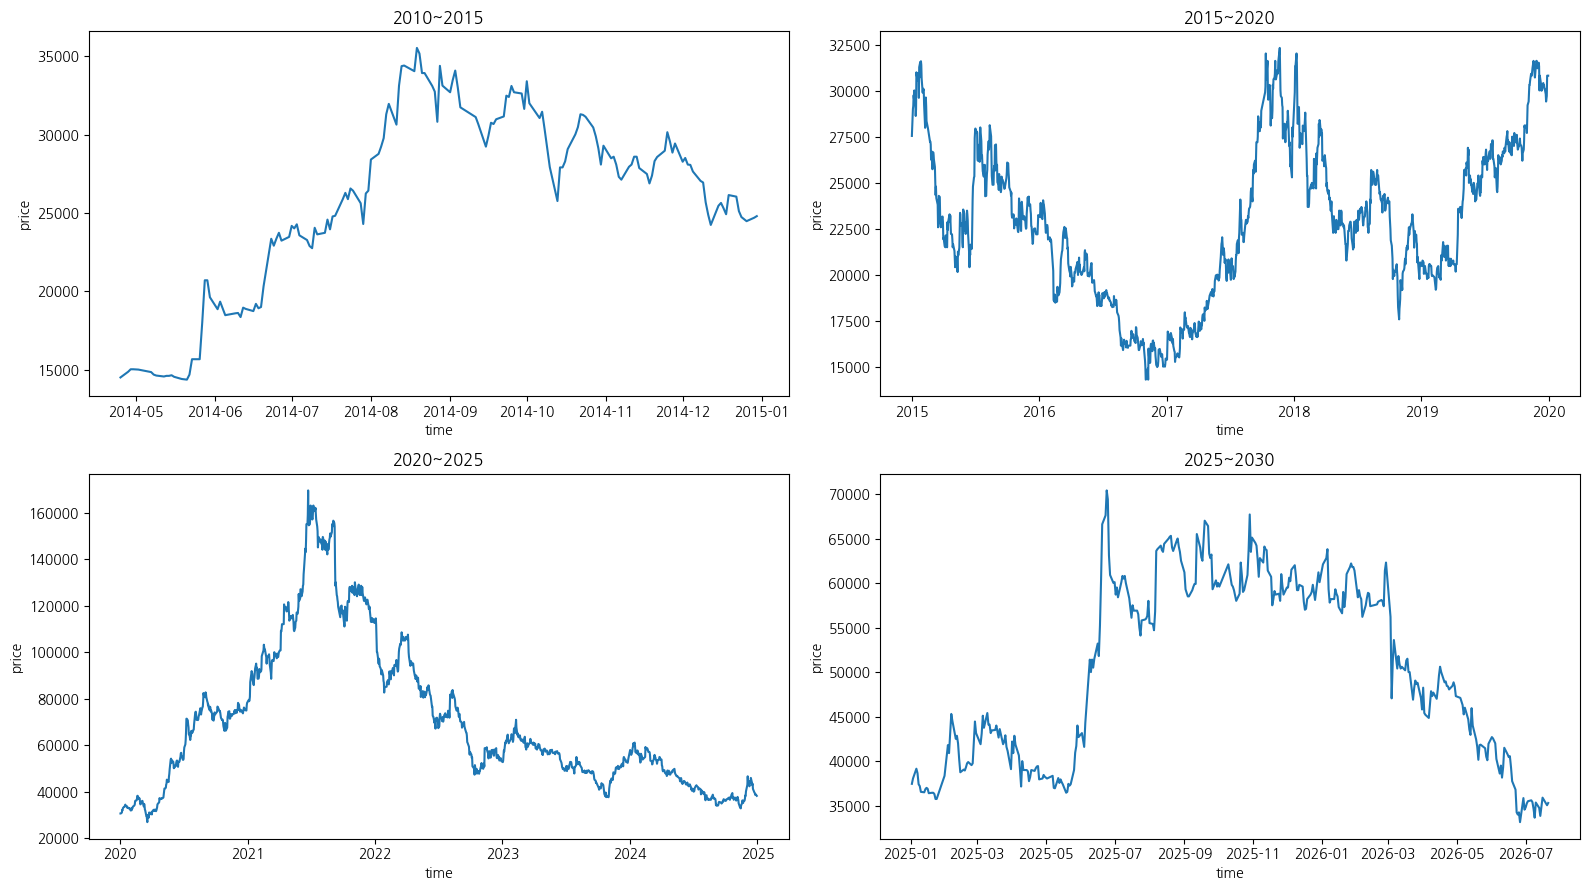

In [65]:
time_steps = [
              ['2010', '2015'],
              ['2015', '2020'],
              ['2020', '2025'],
              ['2025', '2030']]

fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 9)
for i in range(4):
    ax = axes[i//2, i%2]
    df = stock.loc[(stock.index > time_steps[i][0]) & (stock.index < time_steps[i][1])]
    sns.lineplot(y=df['Close'], x=df.index, ax=ax)
    ax.set_title(f'{time_steps[i][0]}~{time_steps[i][1]}')
    ax.set_xlabel('time')
    ax.set_ylabel('price')
plt.tight_layout()
plt.show()

## 데이터 전처리

주가 데이터에 대하여 딥러닝 모델이 더 잘 학습할 수 있도록 **정규화(Normalization)**를 해주도록 하겠습니다.

**표준화 (Standardization)**와 **정규화(Normalization)**에 대한 내용은 아래 링크에서 더 자세히 다루니, 참고해 보시기 바랍니다.

- [데이터 전처리에 관하여](https://teddylee777.github.io/scikit-learn/scikit-learn-preprocessing)

In [66]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# 스케일을 적용할 column을 정의합니다.
scale_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
# 스케일 후 columns
scaled = scaler.fit_transform(stock[scale_cols])
scaled

array([[0.08459884, 0.08515029, 0.08937888, 0.00128875, 0.00402463],
       [0.08448256, 0.08898266, 0.09025466, 0.00362139, 0.01016007],
       [0.08681395, 0.0877052 , 0.09212422, 0.00465239, 0.00440049],
       ...,
       [0.20174419, 0.21069364, 0.2121118 , 0.13911424, 0.14183906],
       [0.20697674, 0.20924855, 0.21335404, 0.13363705, 0.0988394 ],
       [0.20290698, 0.20751445, 0.21273292, 0.13524799, 0.06951647]])

스케일이 완료된 column으로 새로운 데이터프레임을 생성합니다.

**시간 순으로 정렬**되어 있으며, datetime index는 제외했습니다.

*3,000개의 row, 5개 column*으로 이루어진 데이터셋이 DataFrame으로 정리되었습니다.

In [67]:
df = pd.DataFrame(scaled, columns=scale_cols)

## train / test 분할

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['Close']), df['Close'], test_size=0.2, random_state=0, shuffle=False)

In [70]:
x_train.shape, y_train.shape

((2400, 4), (2400,))

In [71]:
x_test.shape, y_test.shape

((600, 4), (600,))

In [72]:
x_train

,Open,High,Low,Volume
0,0.084599,0.085150,0.089379,0.004025
1,0.084483,0.088983,0.090255,0.010160
2,0.086814,0.087705,0.092124,0.004400
3,0.088099,0.087936,0.092373,0.003967
4,0.087285,0.087821,0.093248,0.004052
...,...,...,...,...
2395,0.329651,0.335260,0.351553,0.058254
2396,0.334302,0.332370,0.349689,0.049090
2397,0.327326,0.327746,0.339752,0.096181
2398,0.323837,0.331792,0.345342,0.047891


## TensroFlow Dataset을 활용한 시퀀스 데이터셋 구성

In [73]:
import tensorflow as tf

In [74]:
def windowed_dataset(series, window_size, batch_size, shuffle):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.map(lambda w: (w[:-1], w[-1]))
    return ds.batch(batch_size).prefetch(1)

Hyperparameter를 정의합니다.

In [75]:
WINDOW_SIZE=20
BATCH_SIZE=32

In [76]:
# trian_data는 학습용 데이터셋, test_data는 검증용 데이터셋 입니다.
train_data = windowed_dataset(y_train, WINDOW_SIZE, BATCH_SIZE, True)
test_data = windowed_dataset(y_test, WINDOW_SIZE, BATCH_SIZE, False)

In [77]:
# 아래의 코드로 데이터셋의 구성을 확인해 볼 수 있습니다.
# X: (batch_size, window_size, feature)
# Y: (batch_size, feature)
for data in train_data.take(1):
    print(f'데이터셋(X) 구성(batch_size, window_size, feature갯수): {data[0].shape}')
    print(f'데이터셋(Y) 구성(batch_size, window_size, feature갯수): {data[1].shape}')

데이터셋(X) 구성(batch_size, window_size, feature갯수): (32, 20, 1)
데이터셋(Y) 구성(batch_size, window_size, feature갯수): (32, 1)


## 모델

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Lambda
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model = Sequential([
    # 1차원 feature map 생성
    Conv1D(filters=32, kernel_size=5,
           padding="causal",
           activation="relu",
           input_shape=[WINDOW_SIZE, 1]),
    # LSTM
    LSTM(16, activation='tanh'),
    Dense(16, activation="relu"),
    Dense(1),
])

In [79]:
# Sequence 학습에 비교적 좋은 퍼포먼스를 내는 Huber()를 사용합니다.
loss = Huber()
optimizer = Adam(0.0005)
model.compile(loss=Huber(), optimizer=optimizer, metrics=['mse'])

In [80]:
# earlystopping은 10번 epoch통안 val_loss 개선이 없다면 학습을 멈춥니다.
earlystopping = EarlyStopping(monitor='val_loss', patience=10)
# val_loss 기준 체크포인터도 생성합니다.
filename = os.path.join('tmp', 'checkpointer.weights.h5')
checkpoint = ModelCheckpoint(filename,
                             save_weights_only=True,
                             save_best_only=True,
                             monitor='val_loss',
                             verbose=1)

In [81]:
history = model.fit(train_data,
                    validation_data=(test_data),
                    epochs=50,
                    callbacks=[checkpoint, earlystopping])

Epoch 1/50
     71/Unknown 3s 9ms/step - loss: 0.0046 - mse: 0.0092
Epoch 1: val_loss improved from None to 0.00028, saving model to tmp/checkpointer.weights.h5

Epoch 1: finished saving model to tmp/checkpointer.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0047 - mse: 0.0094 - val_loss: 2.7558e-04 - val_mse: 5.5115e-04
Epoch 2/50
72/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7535e-04 - mse: 3.5069e-04
Epoch 2: val_loss improved from 0.00028 to 0.00019, saving model to tmp/checkpointer.weights.h5

Epoch 2: finished saving model to tmp/checkpointer.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.7974e-04 - mse: 5.5947e-04 - val_loss: 1.8857e-04 - val_mse: 3.7714e-04
Epoch 3/50
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6041e-04 - mse: 3.2082e-04
Epoch 3: val_loss improved from 0.00019 to 0.00018, saving model to tmp/checkpointer.weights.h5

Epoch 3: finished saving model to tmp/checkpointer.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 

저장한 ModelCheckpoint 를 로드합니다.

In [82]:
model.load_weights(filename)

`test_data`를 활용하여 예측을 진행합니다.

In [83]:
pred = model.predict(test_data)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [84]:
pred.shape

(580, 1)

## 예측 데이터 시각화

## Resources
NanumGothic 폰트를 설치해 주세요.

아래 시각화 코드중 y_test 데이터에 **[20:]**으로 슬라이싱을 한 이유는

예측 데이터에서 20일치의 데이터로 21일치를 예측해야하기 때문에 test_data로 예측 시 *앞의 20일은 예측하지 않습니다.*

따라서, 20번 째 index와 비교하면 더욱 정확합니다.

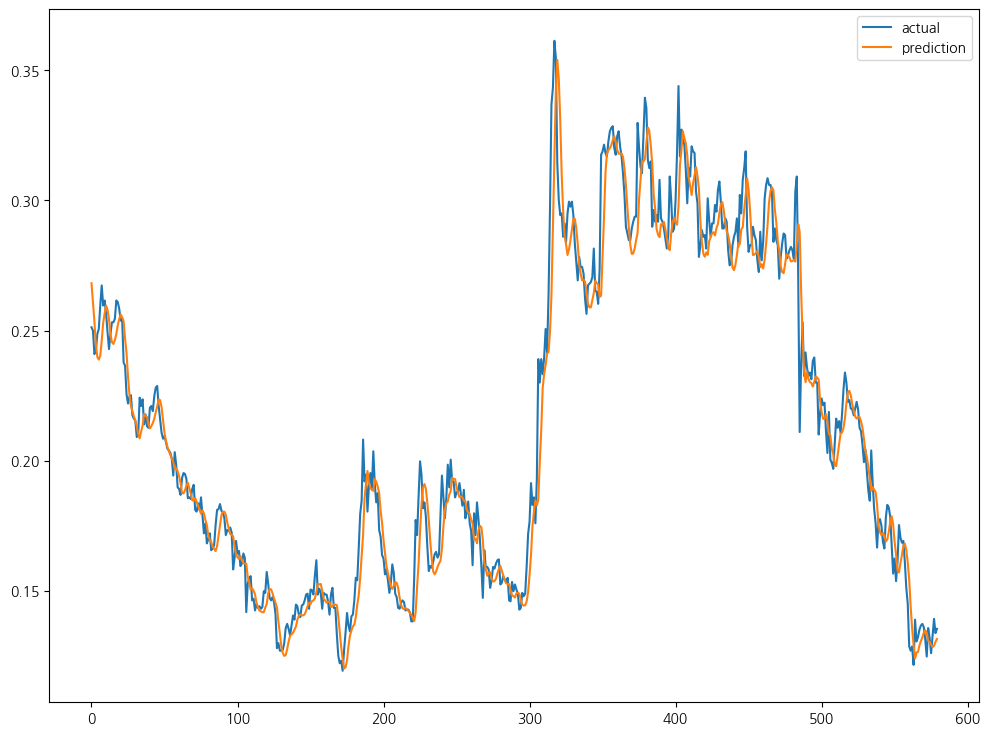

In [85]:
plt.figure(figsize=(12, 9))
plt.plot(np.asarray(y_test)[20:], label='actual')
plt.plot(pred, label='prediction')
plt.legend()
plt.show()